In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Rows": [df.duplicated().sum()] * len(df.columns)  # Same for all columns
})

print(report)

df.dropna(axis=0, inplace=True)

                Data Type  Non-Null Count  Null Count  Unique Values  \
male                int64            4240           0              2   
age                 int64            4240           0             39   
education         float64            4135         105              4   
currentSmoker       int64            4240           0              2   
cigsPerDay        float64            4211          29             33   
BPMeds            float64            4187          53              2   
prevalentStroke     int64            4240           0              2   
prevalentHyp        int64            4240           0              2   
diabetes            int64            4240           0              2   
totChol           float64            4190          50            248   
sysBP             float64            4240           0            234   
diaBP             float64            4240           0            146   
BMI               float64            4221          19           

Note in the above report the existence of a few hundred null counts, occurring most commonly in the 'education' and 'glucose' fields.

We tackle this issue using scikit-learn's SimpleImputer to fill in missing values. This imputation method is chosen over the K-Nearest Neighbors imputer because each row is independent of its adjacent one.

Taking notice of our problem fields, we observe that we are dealing with continuous, ordinal, and binary fields, which should be handled differently.
Ordinal data: 'education'
Continuous data: 'cigsPerDay,' 'totChol,' 'BMI,' 'heartRate,' 'glucose'
Binary data: 'BPMeds'

Our strategy for handling these missing values is to impute missing ordinal data with the mode, continuous data with the median, and binary data with the mode as well.

In [4]:
# Handle missing continuous data
from sklearn.impute import SimpleImputer
cols_to_impute = ['glucose', 'cigsPerDay', 'totChol', 'BMI', 'heartRate']
cont_imputer = SimpleImputer(strategy='median')
df[cols_to_impute] = cont_imputer.fit_transform(df[cols_to_impute])

In [11]:
ord_to_impute = ['education', 'BPMeds']
ord_imputer = SimpleImputer(strategy='most_frequent')
df[ord_to_impute] = ord_imputer.fit_transform(df[ord_to_impute])

report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Rows": [df.duplicated().sum()] * len(df.columns)  # Same for all columns
})

print(report)

                Data Type  Non-Null Count  Null Count  Unique Values  \
male                int64            4240           0              2   
age                 int64            4240           0             39   
education         float64            4240           0              4   
currentSmoker       int64            4240           0              2   
cigsPerDay        float64            4240           0             33   
BPMeds            float64            4240           0              2   
prevalentStroke     int64            4240           0              2   
prevalentHyp        int64            4240           0              2   
diabetes            int64            4240           0              2   
totChol           float64            4240           0            248   
sysBP             float64            4240           0            234   
diaBP             float64            4240           0            146   
BMI               float64            4240           0           

<Axes: title={'center': 'Distribution of age in dataset'}, ylabel='Frequency'>

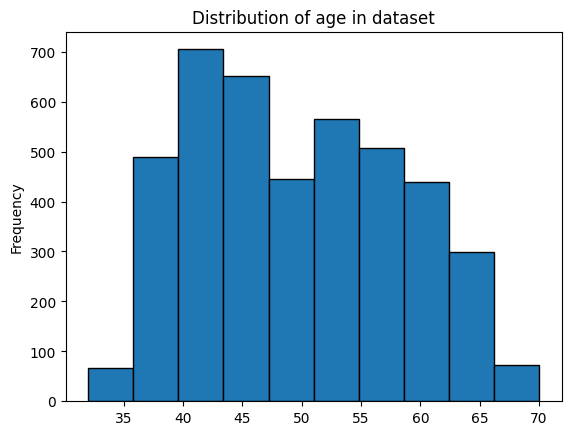

In [20]:
df['age'].plot(kind='hist', bins=10, title="Distribution of age in dataset", edgecolor='black')

<Axes: title={'center': 'Distribution of CHD in dataset'}, ylabel='Frequency'>

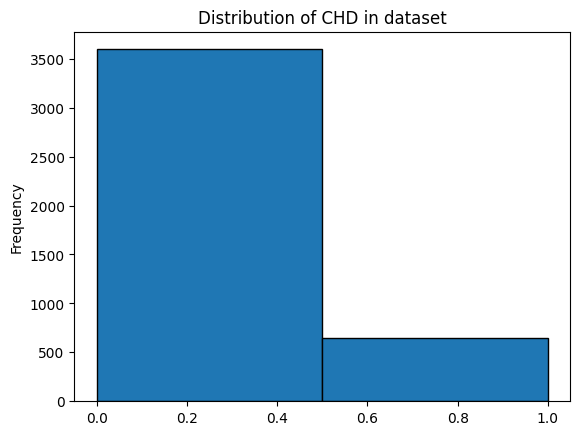

In [21]:
df['TenYearCHD'].plot(kind='hist', bins=2, title="Distribution of CHD in dataset", edgecolor='black')

In [31]:
import numpy as np
from sklearn import preprocessing
X = df[['age','cigsPerDay', 'sysBP', 'totChol', 'glucose']].to_numpy()
y = df['TenYearCHD'].to_numpy()

# normalize dataset
X = preprocessing.StandardScaler().fit(X).transform(X)

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 4)

print('Train set:', X_train.shape, y_train.shape)

Train set: (2560, 5) (2560,)


In [39]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score
print('Model accuracy ', accuracy_score(y_test, prediction))

Model accuracy  0.8451730418943534
